# Comparação de Modelos — TCC

Notebook central que executa todos os modelos, exibe métricas, gráficos comparativos e testes de recomendação de treino.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import polars as pl
from dataset.preprocessamento import preprocessar
from dataset.models.previsao_pace.linear_regression import treina_linear_regression
from dataset.models.previsao_pace.random_forest import treina_random_forest
from dataset.models.previsao_pace.random_forest_regressor import treina_random_forest_regressor
from dataset.models.previsao_tempo.random_forest import treina_random_tempo
from dataset.models.previsao_tempo.regressao_linear import treina_regressao_tempo
from dataset.models.previsao_tempo.xboost import treina_xboost_tempo
from dataset.models.previsao_treino.model import treina_modelo
from dataset.models.previsao_treino.random_forest import treina_rf_recomendacao
from dataset.models.visualizacao import (
    tabela_metricas,
    exibir_detalhes_modelo,
    plotar_comparacao_regressao,
    plotar_comparacao_treino,
    exibir_teste_recomendacao,
    plotar_comparacao_recomendacoes,
    resumo_melhores,
)

In [2]:
df = pl.read_csv(root / "dataset/raw-data-kaggle.csv", separator=";")
df = preprocessar(df)
print(f"Registros: {df.height} | Atletas: {df['athlete'].n_unique()}")

Registros: 40534 | Atletas: 114


## Executar todos os modelos

In [3]:
resultados = {
    "lr_pace": treina_linear_regression(df, plotar=False, verbose=False),
    "rf_pace": treina_random_forest(df, plotar=False, verbose=False),
    "rf_pace_regressor": treina_random_forest_regressor(df, plotar=False, verbose=False),
    "lr_tempo": treina_regressao_tempo(df, plotar=False, verbose=False),
    "rf_tempo": treina_random_tempo(df, plotar=False, verbose=False),
    "xbt_tempo": treina_xboost_tempo(df, plotar=False, verbose=False),
    "regras": treina_modelo(df, plotar=False, verbose=False),
    "rf_treino": treina_rf_recomendacao(df, plotar=False, verbose=False),
}
print("Modelos executados:", list(resultados.keys()))

Modelos executados: ['lr_pace', 'rf_pace', 'rf_pace_regressor', 'lr_tempo', 'rf_tempo', 'xbt_tempo', 'regras', 'rf_treino']


## Tabela comparativa geral

In [4]:
tabela = tabela_metricas(list(resultados.values()))
tabela

modelo,categoria,mae,r2,mse,erro_distribuicao_medio,f1_macro
str,str,f64,f64,f64,f64,f64
"""Regressão Linear (pace)""","""pace""",0.798968,0.467518,null,null,null
"""Random Forest (pace)""","""pace""",0.750698,0.553597,1.221228,null,null
"""Random Forest Regressor (pace)""","""pace""",0.748278,0.555379,null,null,null
"""Regressão Linear (tempo)""","""tempo""",574.086958,0.893996,null,null,null
"""Random Forest (tempo)""","""tempo""",528.57689,0.888292,null,null,null
"""XBoost (tempo)""","""tempo""",502.167593,0.883032,null,null,null
"""Regras (recomendação)""","""treino""",null,null,null,0.763346,null
"""Random Forest (recomendação)""","""treino""",null,null,null,0.776115,0.920072


## Previsão de Pace

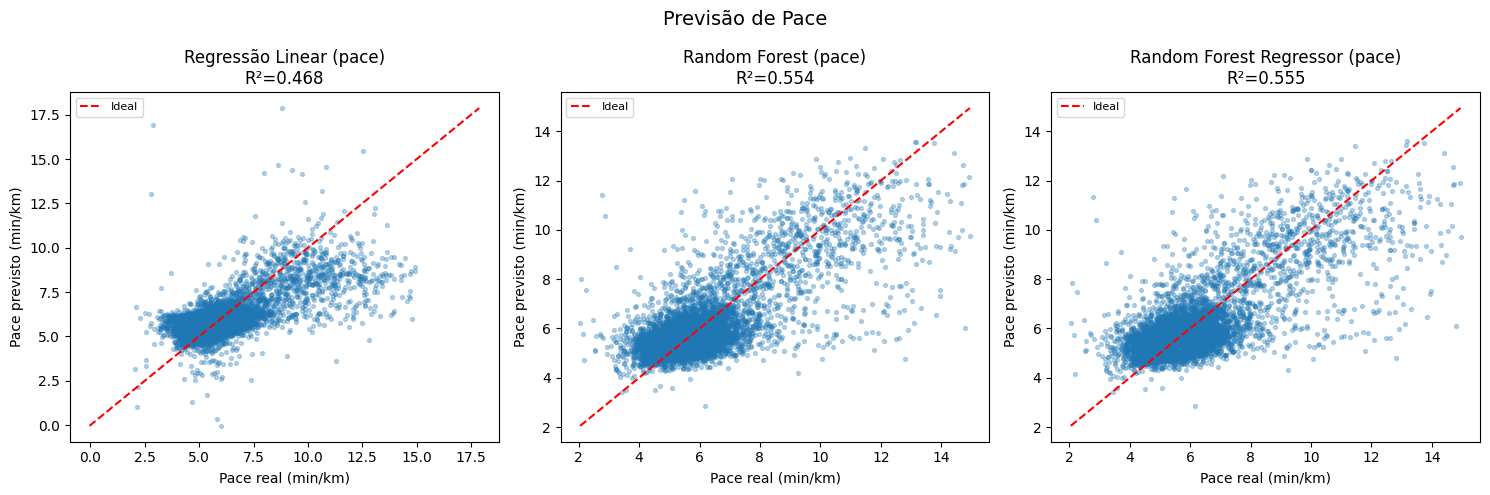

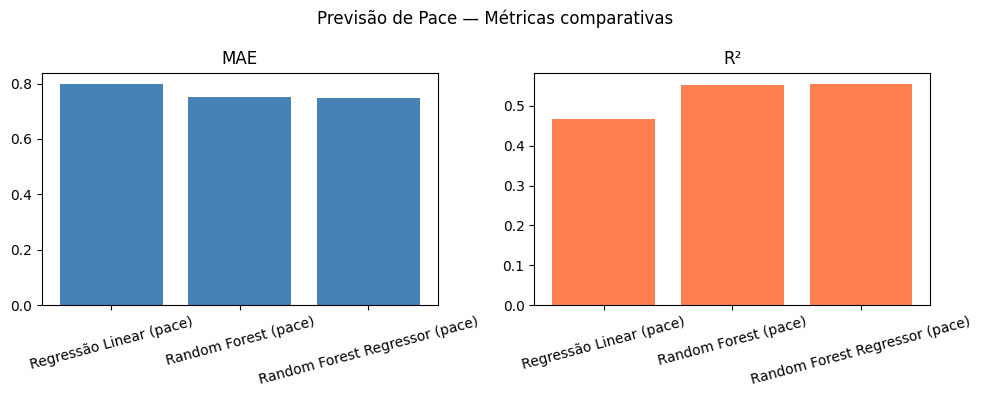


--- Regressão Linear (pace) ---
  mae: 0.7990
  r2: 0.4675
  Coeficientes: {'distance (m)': np.float64(-9.67100829729482e-05), 'elevation gain (m)': np.float64(0.003110899488702276), 'average heart rate (bpm)': np.float64(-0.016559258106922155)}
  Intercepto: 8.77973612163019
  Previsão exemplo: {'entrada': [5000.0, 50.0, 150.0], 'pace_min_km': 5.96784196516224}

--- Random Forest (pace) ---
  mae: 0.7507
  mse: 1.2212
  r2: 0.5536
  Importâncias:
    distance (m): 0.3018
    elevation gain (m): 0.6044
    average heart rate (bpm): 0.0938

--- Random Forest Regressor (pace) ---
  mae: 0.7483
  r2: 0.5554
  Importâncias:
    distance (m): 0.3021
    elevation gain (m): 0.6039
    average heart rate (bpm): 0.0940
  Previsão exemplo: {'entrada': [5000.0, 50.0, 150.0], 'pace_min_km': 5.381989725297278}


In [5]:
pace_results = [resultados["lr_pace"], resultados["rf_pace"], resultados["rf_pace_regressor"]]
plotar_comparacao_regressao(
    pace_results,
    titulo="Previsão de Pace",
    xlabel="Pace real (min/km)",
    ylabel="Pace previsto (min/km)",
)
for r in pace_results:
    exibir_detalhes_modelo(r)

## Previsão de Tempo

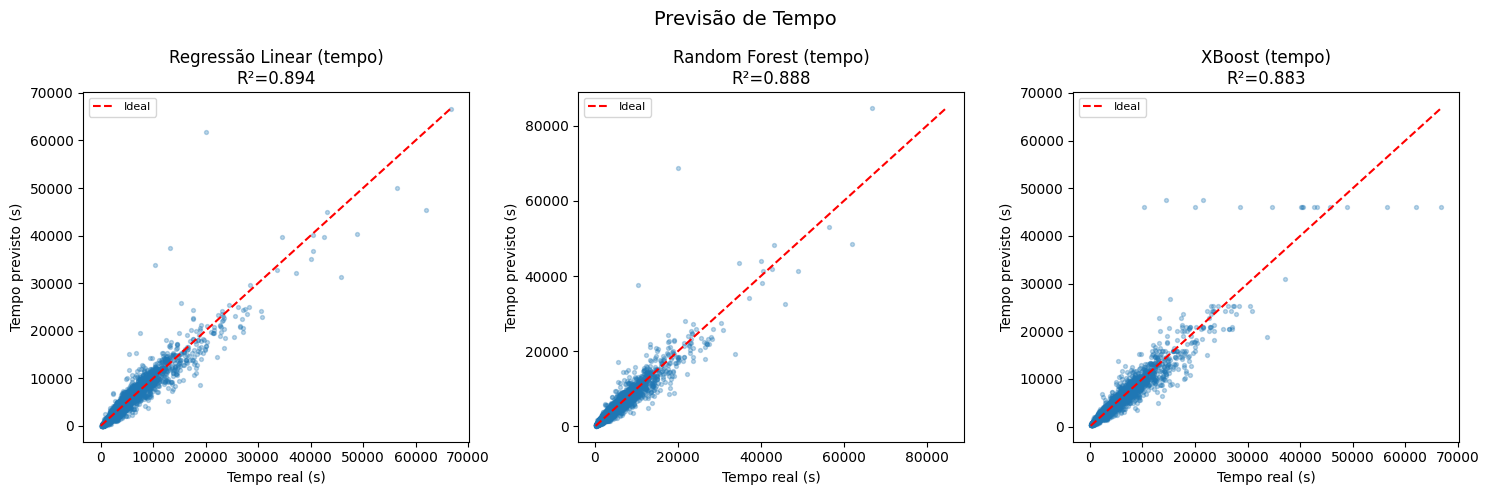

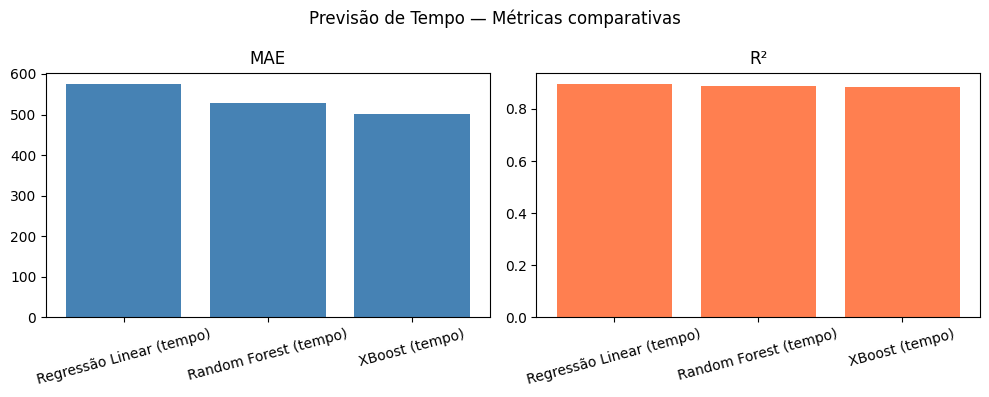


--- Regressão Linear (tempo) ---
  mae: 574.0870
  r2: 0.8940

--- Random Forest (tempo) ---
  mae: 528.5769
  r2: 0.8883

--- XBoost (tempo) ---
  mae: 502.1676
  r2: 0.8830
  Importâncias:
    distance (m): 0.7900
    elevation gain (m): 0.2100


In [6]:
tempo_results = [resultados["lr_tempo"], resultados["rf_tempo"], resultados["xbt_tempo"]]
plotar_comparacao_regressao(
    tempo_results,
    titulo="Previsão de Tempo",
    xlabel="Tempo real (s)",
    ylabel="Tempo previsto (s)",
)
for r in tempo_results:
    exibir_detalhes_modelo(r)

## Métricas de classificação (RF treino)

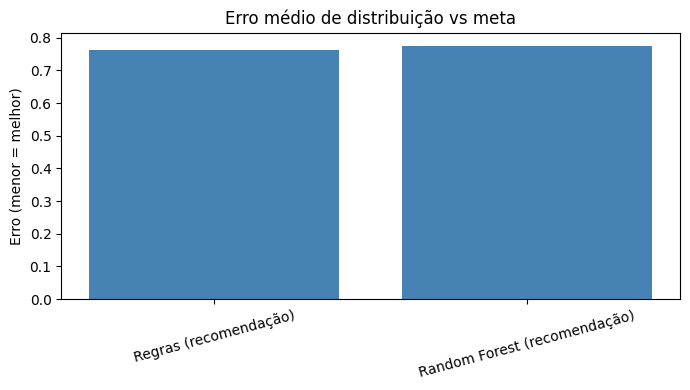

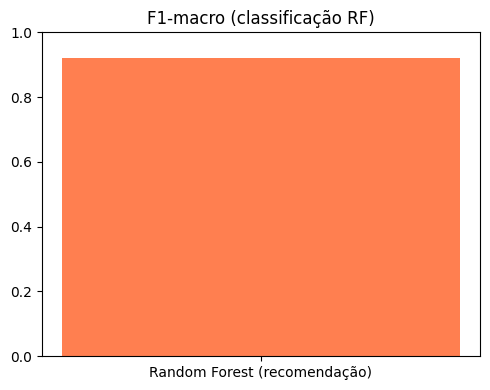

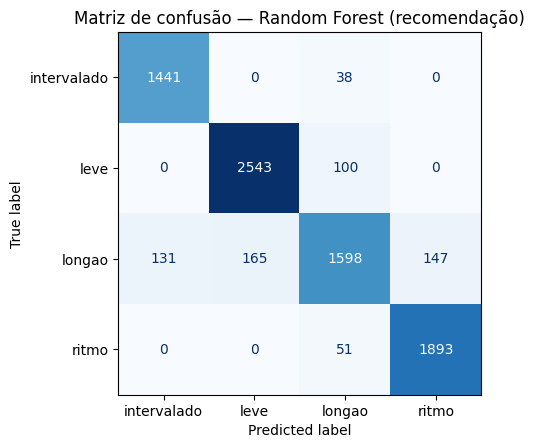


--- Random Forest (recomendação) ---
  f1_macro: 0.9201
  erro_distribuicao_medio: 0.7761
  Importâncias:
    pace_relativo: 0.5522
    distancia_km: 0.3013
    fc_relativa: 0.0788
    elevacao_por_km: 0.0398
    average heart rate (bpm): 0.0280
              precision    recall  f1-score   support

 intervalado      0.917     0.974     0.945      1479
        leve      0.939     0.962     0.950      2643
      longao      0.894     0.783     0.835      2041
       ritmo      0.928     0.974     0.950      1944

    accuracy                          0.922      8107
   macro avg      0.919     0.923     0.920      8107
weighted avg      0.921     0.922     0.920      8107



In [7]:
plotar_comparacao_treino([resultados["regras"], resultados["rf_treino"]])
exibir_detalhes_modelo(resultados["rf_treino"])

## Teste de recomendação — Regras


TESTE DE RECOMENDAÇÃO — Regras (recomendação)

Parâmetros calibrados:
  leve: dist=(7.6, 10.3) km, pace_offset=+0.23
  longao: dist=(14.0, 18.9) km, pace_offset=+0.14
  ritmo: dist=(7.7, 10.4) km, pace_offset=+0.18
  intervalado: dist=(8.1, 11.0) km, pace_offset=-0.69

Erro médio de distribuição vs meta: 0.763

=== Recomendação (Regras (recomendação)) ===
shape: (104, 7)
┌──────────┬────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┐
│ athlete  ┆ tipo   ┆ descricao     ┆ distancia_km ┆ pace_alvo_min ┆ tempo_estimad ┆ erro_distribu │
│ ---      ┆ ---    ┆ ---           ┆ ---          ┆ _km           ┆ o_min         ┆ icao          │
│ i64      ┆ str    ┆ str           ┆ f64          ┆ ---           ┆ ---           ┆ ---           │
│          ┆        ┆               ┆              ┆ f64           ┆ f64           ┆ f64           │
╞══════════╪════════╪═══════════════╪══════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 1776170  ┆ leve  

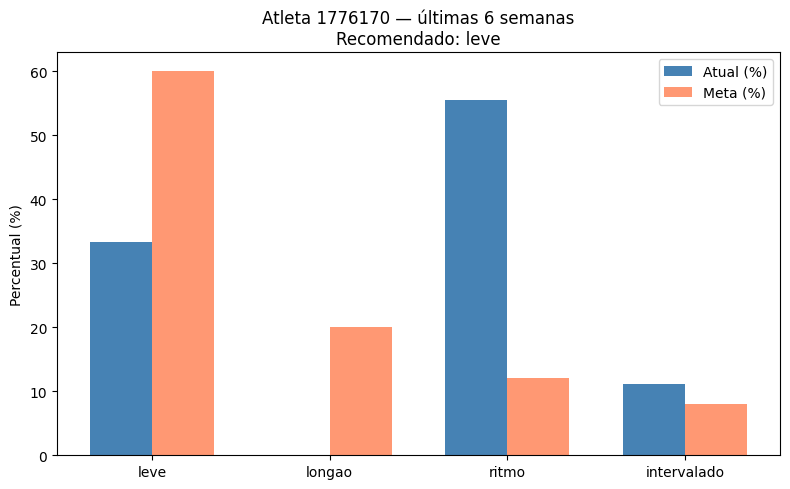

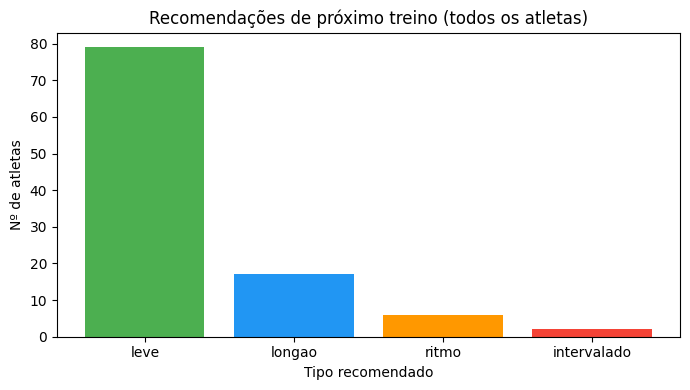

In [8]:
exibir_teste_recomendacao(resultados["regras"], n=5, plotar=True)

## Teste de recomendação — Random Forest


TESTE DE RECOMENDAÇÃO — Random Forest (recomendação)

Parâmetros calibrados:
  leve: dist=(7.6, 10.3) km, pace_offset=+0.24
  longao: dist=(14.5, 19.6) km, pace_offset=+0.14
  ritmo: dist=(7.8, 10.5) km, pace_offset=+0.18
  intervalado: dist=(8.3, 11.2) km, pace_offset=-0.68

Erro médio de distribuição vs meta: 0.776

=== Recomendação (Random Forest (recomendação)) ===
shape: (104, 7)
┌──────────┬────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┐
│ athlete  ┆ tipo   ┆ descricao     ┆ distancia_km ┆ pace_alvo_min ┆ tempo_estimad ┆ erro_distribu │
│ ---      ┆ ---    ┆ ---           ┆ ---          ┆ _km           ┆ o_min         ┆ icao          │
│ i64      ┆ str    ┆ str           ┆ f64          ┆ ---           ┆ ---           ┆ ---           │
│          ┆        ┆               ┆              ┆ f64           ┆ f64           ┆ f64           │
╞══════════╪════════╪═══════════════╪══════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 177

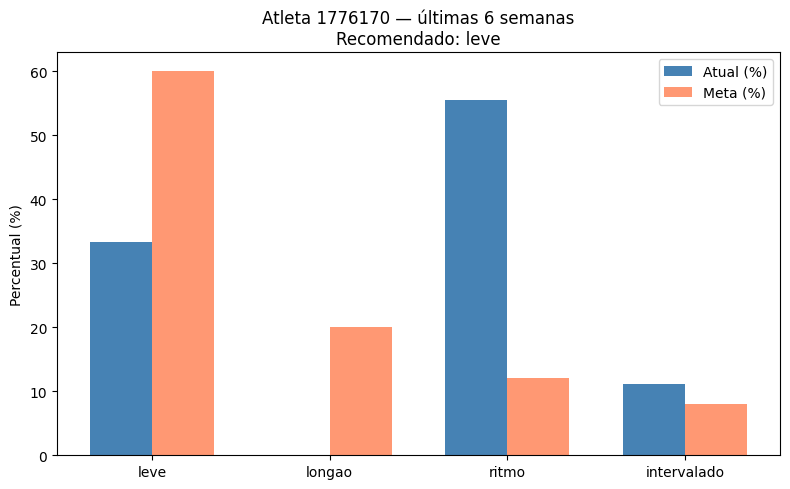

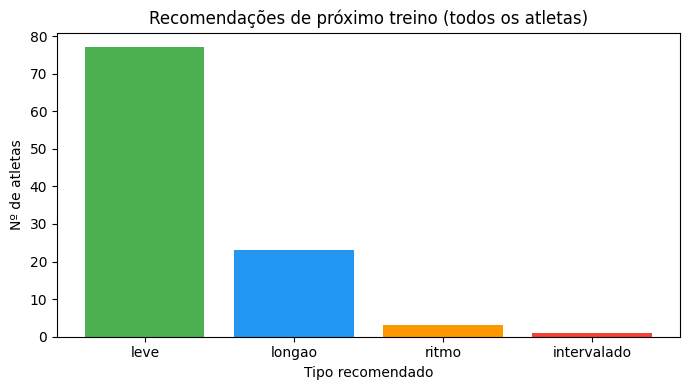

In [9]:
exibir_teste_recomendacao(resultados["rf_treino"], n=5, plotar=True)

## Comparação lado a lado — Regras vs RF

In [10]:
comparacao_treino = tabela.filter(pl.col("categoria") == "treino")
comparacao_treino.select("modelo", "erro_distribuicao_medio", "f1_macro")

modelo,erro_distribuicao_medio,f1_macro
str,f64,f64
"""Regras (recomendação)""",0.763346,null
"""Random Forest (recomendação)""",0.776115,0.920072


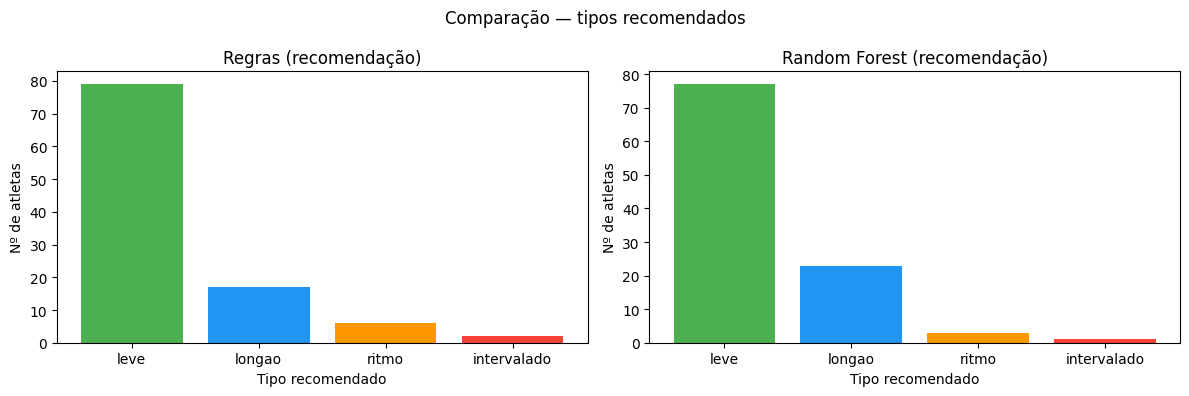

In [11]:
plotar_comparacao_recomendacoes([resultados["regras"], resultados["rf_treino"]])

## Resumo

In [12]:
resumo_melhores(list(resultados.values()))


RESUMO — Melhor modelo por categoria
  Pace (menor MAE): Random Forest Regressor (pace) — MAE=0.7483, R²=0.5554
  Tempo (menor MAE): XBoost (tempo) — MAE=502.1676, R²=0.8830
  Treino (menor erro distribuição): Regras (recomendação) — erro=0.7633
